In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("cirrhosis.csv")
display(df.head())
print(df.info())

X = df.drop(columns=["Status"])
y = df["Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Shapes:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             418 non-null    int64  
 1   N_Days         418 non-null    int64  
 2   Status         418 non-null    object 
 3   Drug           312 non-null    object 
 4   Age            418 non-null    int64  
 5   Sex            418 non-null    object 
 6   Ascites        312 non-null    object 
 7   Hepatomegaly   312 non-null    object 
 8   Spiders        312 non-null    object 
 9   Edema          418 non-null    object 
 10  Bilirubin      418 non-null    float64
 11  Cholesterol    284 non-null    float64
 12  Albumin        418 non-null    float64
 13  Copper         310 non-null    float64
 14  Alk_Phos       312 non-null    float64
 15  SGOT           312 non-null    float64
 16  Tryglicerides  282 non-null    float64
 17  Platelets      407 non-null    float64
 18  Prothrombi

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train.select_dtypes(include=["object"]).columns

numeric_transformer = SimpleImputer(strategy="median")

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

dt_baseline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42
    ))
])

dt_baseline.fit(X_train, y_train)

y_pred = dt_baseline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print(classification_report(y_test, y_pred, zero_division=0))


Accuracy : 0.7143
Precision: 0.6796
Recall   : 0.7143
F1-score : 0.6965
              precision    recall  f1-score   support

           C       0.74      0.79      0.76        47
          CL       0.00      0.00      0.00         5
           D       0.70      0.72      0.71        32

    accuracy                           0.71        84
   macro avg       0.48      0.50      0.49        84
weighted avg       0.68      0.71      0.70        84



In [ ]:
попробуем улучшить 
опять проблема с CV, пожалуй стоит этот класс игнорировать 

In [31]:
from sklearn.model_selection import GridSearchCV

dt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42
    ))
])

param_grid = {
    "model__max_depth": [None, 3, 5, 7, 10],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 5, 10]
}

dt_grid = GridSearchCV(
    dt_pipeline,
    param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

best_dt = dt_grid.best_estimator_

y_pred_best = best_dt.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred_best, average="weighted")
f1 = f1_score(y_test, y_pred_best, average="weighted")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print(classification_report(y_test, y_pred_best, zero_division=0))


Accuracy : 0.7143
Precision: 0.6956
Recall   : 0.7143
F1-score : 0.7045
              precision    recall  f1-score   support

           C       0.76      0.81      0.78        47
          CL       0.00      0.00      0.00         5
           D       0.71      0.69      0.70        32

    accuracy                           0.71        84
   macro avg       0.49      0.50      0.49        84
weighted avg       0.70      0.71      0.70        84



In [ ]:
f1 стало немного лучше
теперь авторская реализация

In [39]:
import numpy as np
from collections import Counter
from sklearn.metrics import accuracy_score, f1_score


class MyDecisionTreeClassifier:
    def __init__(self, max_depth=5, min_samples_split=10):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None

    def _gini(self, y):
        counts = Counter(y)
        probs = [count / len(y) for count in counts.values()]
        return 1 - sum(p ** 2 for p in probs)

    def _best_split(self, X, y):
        best_gini = float("inf")
        best_feature, best_threshold = None, None

        for feature in range(X.shape[1]):
            thresholds = np.unique(X[:, feature])

            for threshold in thresholds:
                left_idx = X[:, feature] <= threshold
                right_idx = X[:, feature] > threshold

                if left_idx.sum() < self.min_samples_split or right_idx.sum() < self.min_samples_split:
                    continue

                gini = (
                    len(y[left_idx]) / len(y) * self._gini(y[left_idx]) +
                    len(y[right_idx]) / len(y) * self._gini(y[right_idx])
                )

                if gini < best_gini:
                    best_gini = gini
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold

    def _build_tree(self, X, y, depth):
        if (
            depth >= self.max_depth
            or len(set(y)) == 1
            or len(y) < self.min_samples_split
        ):
            return Counter(y).most_common(1)[0][0]

        feature, threshold = self._best_split(X, y)

        if feature is None:
            return Counter(y).most_common(1)[0][0]

        left_idx = X[:, feature] <= threshold
        right_idx = X[:, feature] > threshold

        return {
            "feature": feature,
            "threshold": threshold,
            "left": self._build_tree(X[left_idx], y[left_idx], depth + 1),
            "right": self._build_tree(X[right_idx], y[right_idx], depth + 1),
        }

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        self.tree = self._build_tree(X, y, depth=0)
        return self

    def _predict_one(self, x, tree):
        if not isinstance(tree, dict):
            return tree
        if x[tree["feature"]] <= tree["threshold"]:
            return self._predict_one(x, tree["left"])
        else:
            return self._predict_one(x, tree["right"])

    def predict(self, X):
        X = np.asarray(X)
        return np.array([self._predict_one(x, self.tree) for x in X])


In [ ]:
подготовка данных

In [40]:
from scipy import sparse

X_train_proc = best_dt.named_steps["preprocessor"].transform(X_train)
X_test_proc = best_dt.named_steps["preprocessor"].transform(X_test)

if sparse.issparse(X_train_proc):
    X_train_proc = X_train_proc.toarray()
if sparse.issparse(X_test_proc):
    X_test_proc = X_test_proc.toarray()


In [ ]:
обучение и оценки

In [41]:
my_dt = MyDecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10
)

my_dt.fit(X_train_proc, y_train)

y_pred_my = my_dt.predict(X_test_proc)

accuracy = accuracy_score(y_test, y_pred_my)
f1 = f1_score(y_test, y_pred_my, average="weighted", zero_division=0)

print(f"Accuracy : {accuracy:.4f}")
print(f"F1-score : {f1:.4f}")


Accuracy : 0.7262
F1-score : 0.7168


In [ ]:
результат близок к базовой реализации 
Далее визуальное сравнение 

,Model,Accuracy,F1_weighted
0,Decision Tree,0.714286,0.696450
1,Decision Tree улучшенный,0.714286,0.704452
2,My Decision Tree,0.726190,0.716766


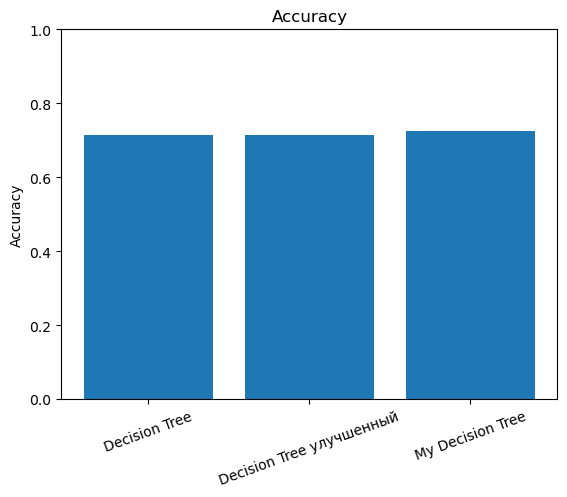

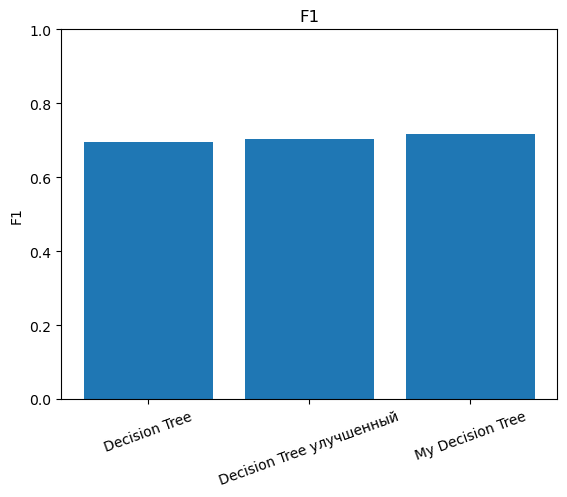

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

y_pred_baseline = dt_baseline.predict(X_test)
y_pred_best = best_dt.predict(X_test)
y_pred_my = y_pred_my  

results_cls = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Decision Tree улучшенный",
        "My Decision Tree"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_baseline),
        accuracy_score(y_test, y_pred_best),
        accuracy_score(y_test, y_pred_my)
    ],
    "F1_weighted": [
        f1_score(y_test, y_pred_baseline, average="weighted", zero_division=0),
        f1_score(y_test, y_pred_best, average="weighted", zero_division=0),
        f1_score(y_test, y_pred_my, average="weighted", zero_division=0)
    ]
})

display(results_cls)

plt.figure()
plt.bar(results_cls["Model"], results_cls["Accuracy"])
plt.title("Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

plt.figure()
plt.bar(results_cls["Model"], results_cls["F1_weighted"])
plt.title("F1")
plt.ylabel("F1")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()


In [ ]:
Регрессия
загрузка  разделение и предобработка данных

In [44]:
df = pd.read_csv("mobile.csv")

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

display(df.head())
print(df.info())

X = df.drop(columns=["Price"])
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Shapes:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


,Brand me,Ratings,RAM,ROM,Mobile_Size,Primary_Cam,Selfi_Cam,Battery_Power,Price
0,"LG V30+ (Black, 128 )",4.3,4.0,128.0,6.00,48,13.0,4000,24999
1,I Kall K11,3.4,6.0,64.0,4.50,48,12.0,4000,15999
2,Nokia 105 ss,4.3,4.0,4.0,4.50,64,16.0,4000,15000
3,"Samsung Galaxy A50 (White, 64 )",4.4,6.0,64.0,6.40,48,15.0,3800,18999
4,"POCO F1 (Steel Blue, 128 )",4.5,6.0,128.0,6.18,35,15.0,3800,18999


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 836 entries, 0 to 835
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Brand me       836 non-null    object 
 1   Ratings        805 non-null    float64
 2   RAM            829 non-null    float64
 3   ROM            832 non-null    float64
 4   Mobile_Size    834 non-null    float64
 5   Primary_Cam    836 non-null    int64  
 6   Selfi_Cam      567 non-null    float64
 7   Battery_Power  836 non-null    int64  
 8   Price          836 non-null    int64  
dtypes: float64(5), int64(3), object(1)
memory usage: 58.9+ KB
None
Shapes:
X_train: (668, 8)
X_test : (168, 8)
y_train: (668,)
y_test : (168,)


In [ ]:
препроцессинг

In [50]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train.select_dtypes(include=["object"]).columns
numeric_transformer = SimpleImputer(strategy="median")

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [ ]:
базовая версия

In [51]:
dt_reg_baseline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(
        random_state=42
    ))
])

dt_reg_baseline.fit(X_train, y_train)
y_pred = dt_reg_baseline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R2 : {r2:.4f}")


MAE: 1537.97
MSE: 66933619.48
R2 : 0.9712


In [ ]:
результат хороший, попробуем улучшить 

In [55]:
dt_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

param_grid = {
    "model__max_depth": [None, 3, 5, 7, 10, 15],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 5, 10]
}

dt_reg_grid = GridSearchCV(
    dt_reg_pipeline,
    param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

dt_reg_grid.fit(X_train, y_train)

print("Best :")
print(dt_reg_grid.best_params_)
print(f"Best CV MAE: {abs(dt_reg_grid.best_score_):.2f}")

best_dt_reg = dt_reg_grid.best_estimator_

y_pred_best = best_dt_reg.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_best)
mse = mean_squared_error(y_test, y_pred_best)
r2 = r2_score(y_test, y_pred_best)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R2 : {r2:.4f}")


Best :
{'model__max_depth': 15, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
Best CV MAE: 4806.94

===== IMPROVED DECISION TREE REGRESSION RESULTS =====
MAE: 1532.78
MSE: 66006090.19
R2 : 0.9716


In [ ]:
результат хороший 
далее авторская реализация

In [57]:
class MyDecisionTreeRegressor:
    def __init__(self, max_depth=5, min_samples_split=10):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None

    def _mse(self, y):
        if len(y) == 0:
            return 0
        return np.mean((y - np.mean(y)) ** 2)

    def _best_split(self, X, y):
        best_mse = float("inf")
        best_feature, best_threshold = None, None

        for feature in range(X.shape[1]):
            thresholds = np.unique(X[:, feature])

            for threshold in thresholds:
                left_idx = X[:, feature] <= threshold
                right_idx = X[:, feature] > threshold

                if (
                    left_idx.sum() < self.min_samples_split
                    or right_idx.sum() < self.min_samples_split
                ):
                    continue

                mse = (
                    len(y[left_idx]) / len(y) * self._mse(y[left_idx]) +
                    len(y[right_idx]) / len(y) * self._mse(y[right_idx])
                )

                if mse < best_mse:
                    best_mse = mse
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold

    def _build_tree(self, X, y, depth):
        if (
            depth >= self.max_depth
            or len(y) < self.min_samples_split
        ):
            return np.mean(y)

        feature, threshold = self._best_split(X, y)

        if feature is None:
            return np.mean(y)

        left_idx = X[:, feature] <= threshold
        right_idx = X[:, feature] > threshold

        return {
            "feature": feature,
            "threshold": threshold,
            "left": self._build_tree(X[left_idx], y[left_idx], depth + 1),
            "right": self._build_tree(X[right_idx], y[right_idx], depth + 1),
        }

    def fit(self, X, y):
        self.tree = self._build_tree(
            np.asarray(X),
            np.asarray(y),
            depth=0
        )
        return self

    def _predict_one(self, x, tree):
        if not isinstance(tree, dict):
            return tree

        if x[tree["feature"]] <= tree["threshold"]:
            return self._predict_one(x, tree["left"])
        else:
            return self._predict_one(x, tree["right"])

    def predict(self, X):
        X = np.asarray(X)
        return np.array([self._predict_one(x, self.tree) for x in X])


In [58]:
X_train_proc = best_dt_reg.named_steps["preprocessor"].transform(X_train)
X_test_proc = best_dt_reg.named_steps["preprocessor"].transform(X_test)

if sparse.issparse(X_train_proc):
    X_train_proc = X_train_proc.toarray()
if sparse.issparse(X_test_proc):
    X_test_proc = X_test_proc.toarray()


In [59]:
my_dt_reg = MyDecisionTreeRegressor(
    max_depth=5,
    min_samples_split=10
)

my_dt_reg.fit(X_train_proc, y_train)

y_pred_my = my_dt_reg.predict(X_test_proc)

mae = mean_absolute_error(y_test, y_pred_my)
mse = mean_squared_error(y_test, y_pred_my)
r2 = r2_score(y_test, y_pred_my)

print("===== MY DECISION TREE REGRESSION RESULTS =====")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R2 : {r2:.4f}")


===== MY DECISION TREE REGRESSION RESULTS =====
MAE: 7979.23
MSE: 1456443016.19
R2 : 0.3736


In [ ]:
R2 больно низкая попробуем улучшить 
увеличим немногоглубину, уменьшим min_samples_split, и добавим минимальный размер листа 

In [63]:
import numpy as np

class MyDecisionTreeRegressorV2:
    def __init__(self, max_depth=10, min_samples_split=5, min_samples_leaf=2, n_thresholds=20):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.n_thresholds = n_thresholds
        self.tree = None

    def _mse(self, y):
        return np.mean((y - y.mean()) ** 2)

    def _best_split(self, X, y):
        best_gain = -1
        best_feature, best_threshold = None, None
        parent_mse = self._mse(y)

        n_samples, n_features = X.shape

        for feature in range(n_features):
            values = X[:, feature]

            thresholds = np.unique(
                np.quantile(values, np.linspace(0, 1, self.n_thresholds))
            )

            for threshold in thresholds:
                left_mask = values <= threshold
                right_mask = values > threshold

                if left_mask.sum() < self.min_samples_leaf or right_mask.sum() < self.min_samples_leaf:
                    continue

                left_y = y[left_mask]
                right_y = y[right_mask]

                mse_left = self._mse(left_y)
                mse_right = self._mse(right_y)

                gain = parent_mse - (
                    (len(left_y)/n_samples)*mse_left +
                    (len(right_y)/n_samples)*mse_right
                )

                if gain >best_gain:
                    best_gain =gain
                    best_feature = feature
                    best_threshold= threshold

        return best_feature, best_threshold

    def _build_tree(self, X, y, depth):
        if depth >= self.max_depth or len(y) < self.min_samples_split:
            return np.mean(y)

        feature, threshold = self._best_split(X, y)
        if feature is None: 
            return np.mean(y)

        left_mask = X[:, feature] <= threshold
        right_mask = X[:, feature] > threshold

        return {
            "feature": feature,
            "threshold": threshold,
            "left": self._build_tree(X[left_mask], y[left_mask], depth + 1),
            "right": self._build_tree(X[right_mask], y[right_mask], depth + 1),
        }

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        self.tree = self._build_tree(X, y, 0)
        return self

    def _predict_one(self, x, tree):
        if not isinstance(tree, dict):
            return tree
        if x[tree["feature"]] <= tree["threshold"]:
            return self._predict_one(x, tree["left"])
        else:
            return self._predict_one(x, tree["right"])

    def predict(self, X):
        X = np.asarray(X)
        return np.array([self._predict_one(x, self.tree) for x in X])


In [66]:
my_dt_reg2 = MyDecisionTreeRegressorV2(
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    n_thresholds= 40 
)

my_dt_reg2.fit(X_train_proc, y_train)

y_pred_my2 = my_dt_reg2.predict(X_test_proc)
print(f"MAE: {mean_absolute_error(y_test, y_pred_my2):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_my2):.2f}")
print(f"R2 : {r2_score(y_test, y_pred_my2):.4f}")


MAE: 3013.23
MSE: 97850279.66
R2 : 0.9579


In [ ]:
результат стал лучше 

In [ ]:
далее блок визуализации результатов

,Model,R2
0,Decision Tree базовый,0.971211
1,Decision Tree базовый улучшенный,0.971610
2,My Decision Tree,0.373566
3,My Decision Tree улучшенный,0.957913


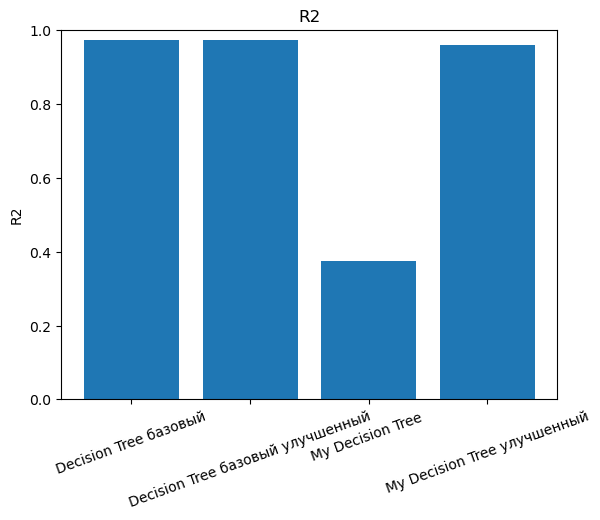

In [70]:
y_pred_baseline = dt_reg_baseline.predict(X_test)
y_pred_best = best_dt_reg.predict(X_test)
y_pred_my_old = y_pred_my        
y_pred_my_new = y_pred_my2

results_r2 = pd.DataFrame({
    "Model": [
        "Decision Tree базовый",
        "Decision Tree базовый улучшенный",
        "My Decision Tree ",
        "My Decision Tree улучшенный"
    ],
    "R2": [
        r2_score(y_test, y_pred_baseline),
        r2_score(y_test, y_pred_best),
        r2_score(y_test, y_pred_my_old),
        r2_score(y_test, y_pred_my_new),
    ]
})

display(results_r2)

plt.figure()
plt.bar(results_r2["Model"], results_r2["R2"])
plt.title("R2")
plt.ylabel("R2")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()
